#Understanding and Prepping Data

In [24]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.api as sm

In [3]:
dt = pd.read_csv('AICPA_regressionAnalysisData.csv')
display(dt)

,type,date,revenue,production,coolDD,heatDD
0,dt4training,2011-01-31,23304096,659640,0,1021
1,dt4training,2011-02-28,24552000,686144,0,794
2,dt4training,2011-03-31,14804728,416464,0,714
3,dt4training,2011-04-30,11265320,324456,1,354
4,dt4training,2011-05-31,5945904,151104,72,114
5,dt4training,2011-06-30,10379712,479264,239,4
6,dt4training,2011-07-31,13617528,708472,486,0
7,dt4training,2011-08-31,14092512,687728,346,0
8,dt4training,2011-09-30,12085472,567424,195,19
9,dt4training,2011-10-31,11957032,392328,24,223


In [4]:
dt.head(2)

,type,date,revenue,production,coolDD,heatDD
0,dt4training,2011-01-31,23304096,659640,0,1021
1,dt4training,2011-02-28,24552000,686144,0,794


In [5]:
dt.tail(2)

,type,date,revenue,production,coolDD,heatDD
46,dt4testing,2014-11-30,10164048,293536,0,579
47,dt4testing,2014-12-31,18377456,567048,0,752


In [7]:
dt.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48 entries, 0 to 47
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   type        48 non-null     object
 1   date        48 non-null     object
 2   revenue     48 non-null     int64 
 3   production  48 non-null     int64 
 4   coolDD      48 non-null     int64 
 5   heatDD      48 non-null     int64 
dtypes: int64(4), object(2)
memory usage: 2.4+ KB


#Visualizing Monthly Revenue

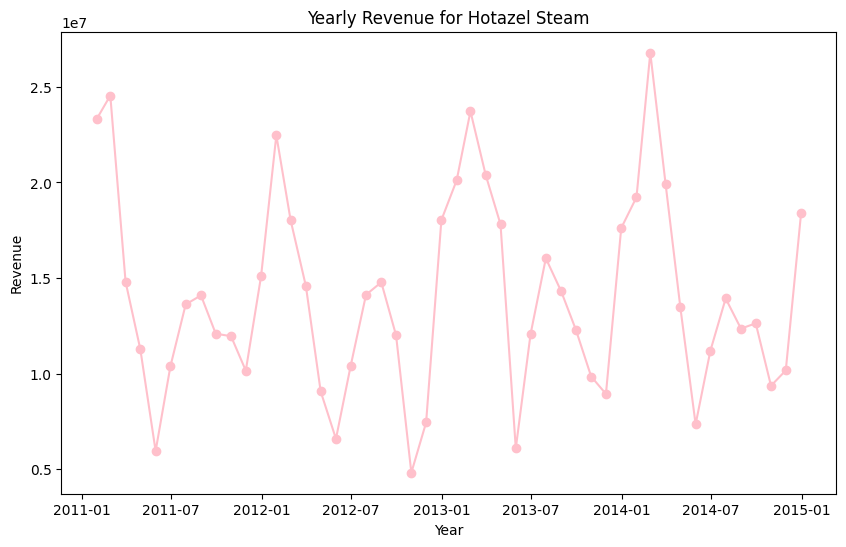

In [10]:
plt.figure(figsize=(10, 6))

plt.title('Yearly Revenue for Hotazel Steam')
plt.xlabel('Year')
plt.ylabel('Revenue')

dt['date'] = pd.to_datetime(dt['date'])

plt.plot(dt['date'], dt['revenue'], color = 'pink', marker ='o')

##Heating vs Cooling

In [14]:
dt['byUse'] = np.where(dt['heatDD'] > dt['coolDD'], 'heating', 'cooling')
dt.sample(5)

,type,date,revenue,production,coolDD,heatDD,byUse
5,dt4training,2011-06-30,10379712,479264,239,4,cooling
40,dt4testing,2014-05-31,7344128,279296,49,88,heating
31,dt4training,2013-08-31,14311800,642688,340,0,cooling
27,dt4training,2013-04-30,17811224,427312,0,366,heating
16,dt4training,2012-05-31,6582400,217264,102,69,cooling


([<matplotlib.axis.XTick at 0x7f6910d828d0>,
 [Text(15340.0, 0, '2012'),
  Text(15706.0, 0, '2013'),
  Text(16071.0, 0, '2014')])

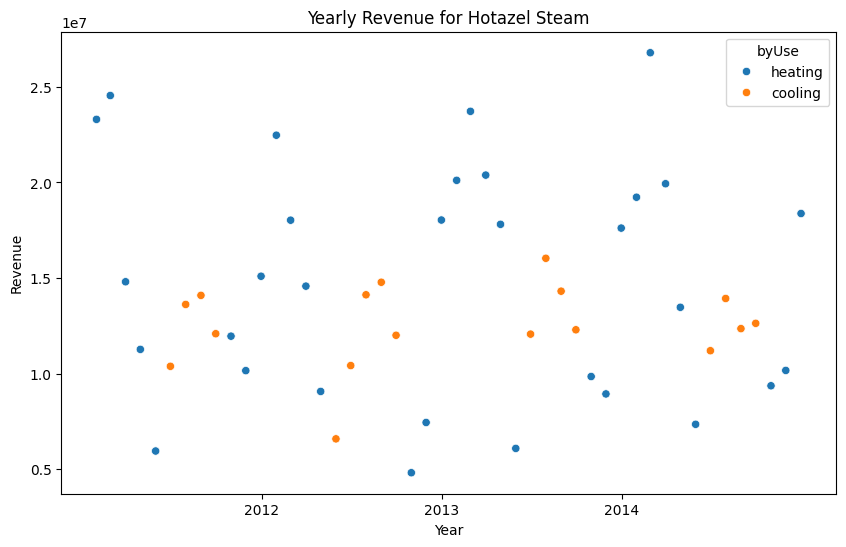

In [16]:
plt.figure(figsize=(10, 6))
plt.title('Yearly Revenue for Hotazel Steam')

sns.scatterplot(data=dt, x='date', y='revenue', hue='byUse', marker='o')

plt.xlabel('Year')
plt.ylabel('Revenue')

date_range = pd.date_range(start=dt['date'].min(), end=dt['date'].max(), freq='YS')
plt.xticks(date_range, date_range.year)

## Revenue vs Production


Text(0, 0.5, 'Revenue')

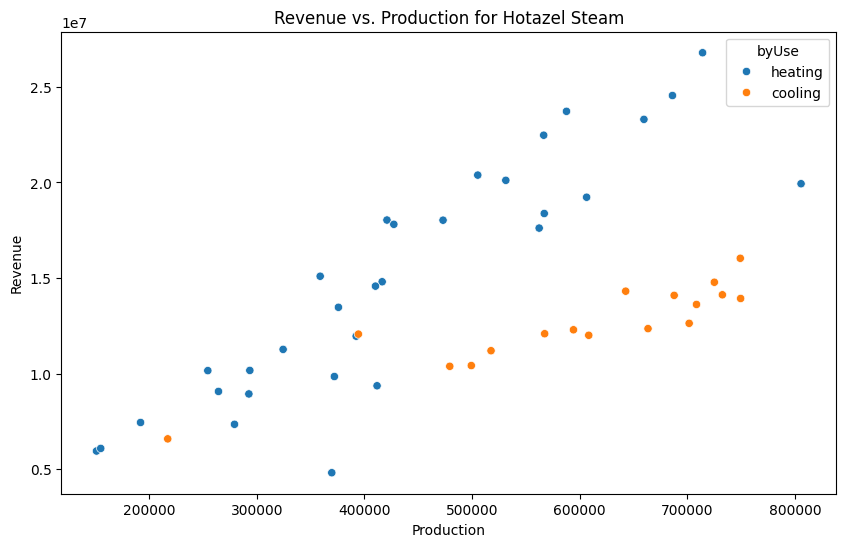

In [18]:
plt.figure(figsize=(10, 6))
plt.title('Revenue vs. Production for Hotazel Steam')

sns.scatterplot(data=dt, x='production', y='revenue', hue='byUse', marker='o')

plt.xlabel('Production')
plt.ylabel('Revenue')

#Correlation Analysis

In [19]:
dt[['revenue',  'production',   'coolDD',   'heatDD']].corr()

,revenue,production,coolDD,heatDD
revenue,1.000000,0.632091,-0.169433,0.686901
production,0.632091,1.000000,0.509203,0.032060
coolDD,-0.169433,0.509203,1.000000,-0.716721
heatDD,0.686901,0.032060,-0.716721,1.000000


#Training vs Testing Data

In [20]:
pd.crosstab(dt['type'],'count')

col_0,count
type,
dt4testing,12
dt4training,36


In [21]:
dt4training = dt.loc[dt['type'] == 'dt4training']
dt4testing = dt.loc[dt['type'] == 'dt4testing']
display(dt4training)

,type,date,revenue,production,coolDD,heatDD,byUse
0,dt4training,2011-01-31,23304096,659640,0,1021,heating
1,dt4training,2011-02-28,24552000,686144,0,794,heating
2,dt4training,2011-03-31,14804728,416464,0,714,heating
3,dt4training,2011-04-30,11265320,324456,1,354,heating
4,dt4training,2011-05-31,5945904,151104,72,114,heating
5,dt4training,2011-06-30,10379712,479264,239,4,cooling
6,dt4training,2011-07-31,13617528,708472,486,0,cooling
7,dt4training,2011-08-31,14092512,687728,346,0,cooling
8,dt4training,2011-09-30,12085472,567424,195,19,cooling
9,dt4training,2011-10-31,11957032,392328,24,223,heating


In [22]:
display(dt4testing)

,type,date,revenue,production,coolDD,heatDD,byUse
36,dt4testing,2014-01-31,19228840,606400,0,1123,heating
37,dt4testing,2014-02-28,26792280,714128,0,938,heating
38,dt4testing,2014-03-31,19935840,805600,0,866,heating
39,dt4testing,2014-04-30,13468000,375856,0,412,heating
40,dt4testing,2014-05-31,7344128,279296,49,88,heating
41,dt4testing,2014-06-30,11196216,517600,230,0,cooling
42,dt4testing,2014-07-31,13929472,749472,380,0,cooling
43,dt4testing,2014-08-31,12352176,663432,322,0,cooling
44,dt4testing,2014-09-30,12628944,701656,178,14,cooling
45,dt4testing,2014-10-31,9361000,411728,24,166,heating


#Simple Linear Regression

In [25]:
X = dt4training.loc[:, 'production']
y = dt4training.loc[:, 'revenue']

X = sm.add_constant(X)

model1 = sm.OLS(y, X).fit()

model1.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                revenue   R-squared:                       0.397
Model:                            OLS   Adj. R-squared:                  0.379
Method:                 Least Squares   F-statistic:                     22.35
Date:                Thu, 30 Jul 2026   Prob (F-statistic):           3.86e-05
Time:                        18:31:59   Log-Likelihood:                -598.32
No. Observations:                  36   AIC:                             1201.
Df Residuals:                      34   BIC:                             1204.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       4.898e+06   2.01e+06      2.431      0.020    8.03e+05    8.99e+06
production    18.9920      4.017      4.728      0.000      10.828      27.156
==============================================================================
Omnibus:                        5.412   Durbin-Watson:                   0.444
Prob(Omnibus):                  0.067   Jarque-Bera (JB):                2.625
Skew:                           0.392   Prob(JB):                        0.269
Kurtosis:                       1.934   Cond. No.                     1.47e+06
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 1.47e+06. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

In [26]:
pd.options.display.float_format = '{:.2f}'.format
model1.params

,0
const,4897663.26
production,18.99


Regression Model: Revenue = 4897663 +18.99*Production

If production increases by one unit (1000 pounds), revenues will increase by 18.99

#Evaluation and Communication

In [29]:
dt4testing.head(1)

,type,date,revenue,production,coolDD,heatDD,byUse
36,dt4testing,2014-01-31,19228840,606400,0,1123,heating


In [30]:
X_test = sm.add_constant(dt4testing.loc[:,['production']])

In [31]:
predictions = model1.predict(X_test)

In [32]:
display(predictions)

,0
36,16414428.69
37,18460401.82
38,20197640.55
39,12035930.72
40,10202060.55
41,14727936.65
42,19131656.04
43,17497582.00
44,18223533.25
45,12717212.73


In [33]:
dt4testing_predictions = dt4testing
dt4testing_predictions['lm_predicted'] = predictions

display(dt4testing_predictions)

/tmp/ipykernel_2569/737641467.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dt4testing_predictions['lm_predicted'] = predictions


,type,date,revenue,production,coolDD,heatDD,byUse,lm_predicted
36,dt4testing,2014-01-31,19228840,606400,0,1123,heating,16414428.69
37,dt4testing,2014-02-28,26792280,714128,0,938,heating,18460401.82
38,dt4testing,2014-03-31,19935840,805600,0,866,heating,20197640.55
39,dt4testing,2014-04-30,13468000,375856,0,412,heating,12035930.72
40,dt4testing,2014-05-31,7344128,279296,49,88,heating,10202060.55
41,dt4testing,2014-06-30,11196216,517600,230,0,cooling,14727936.65
42,dt4testing,2014-07-31,13929472,749472,380,0,cooling,19131656.04
43,dt4testing,2014-08-31,12352176,663432,322,0,cooling,17497582.00
44,dt4testing,2014-09-30,12628944,701656,178,14,cooling,18223533.25
45,dt4testing,2014-10-31,9361000,411728,24,166,heating,12717212.73


#Percentage Error

In [34]:
dt4testing_predictions['lm_pctErr'] = (
    abs(100 * (dt4testing['revenue'] - dt4testing['lm_predicted']) / dt4testing['revenue'])
    )
display(dt4testing_predictions)

/tmp/ipykernel_2569/232810988.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dt4testing_predictions['lm_pctErr'] = (


,type,date,revenue,production,coolDD,heatDD,byUse,lm_predicted,lm_pctErr
36,dt4testing,2014-01-31,19228840,606400,0,1123,heating,16414428.69,14.64
37,dt4testing,2014-02-28,26792280,714128,0,938,heating,18460401.82,31.10
38,dt4testing,2014-03-31,19935840,805600,0,866,heating,20197640.55,1.31
39,dt4testing,2014-04-30,13468000,375856,0,412,heating,12035930.72,10.63
40,dt4testing,2014-05-31,7344128,279296,49,88,heating,10202060.55,38.91
41,dt4testing,2014-06-30,11196216,517600,230,0,cooling,14727936.65,31.54
42,dt4testing,2014-07-31,13929472,749472,380,0,cooling,19131656.04,37.35
43,dt4testing,2014-08-31,12352176,663432,322,0,cooling,17497582.00,41.66
44,dt4testing,2014-09-30,12628944,701656,178,14,cooling,18223533.25,44.30
45,dt4testing,2014-10-31,9361000,411728,24,166,heating,12717212.73,35.85


In [35]:
err_mean = dt4testing_predictions['lm_pctErr'].mean()
display(err_mean)

np.float64(25.42315606071484)

Visualizing

([], [])

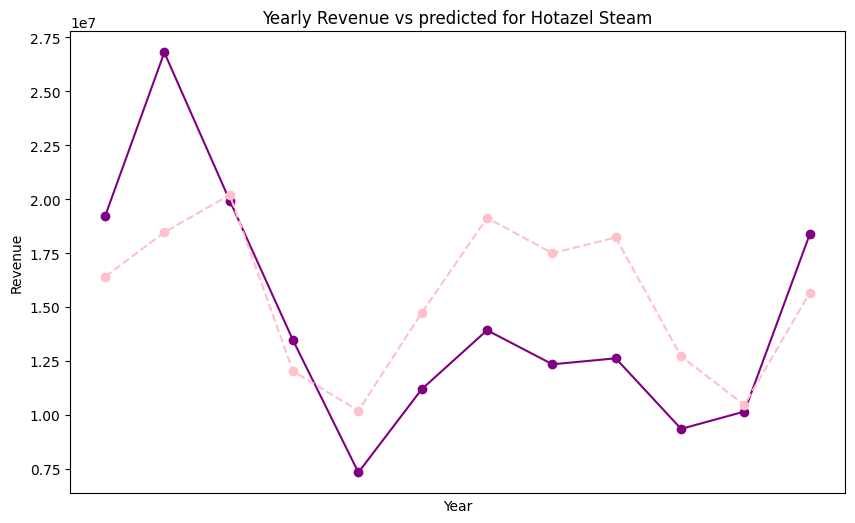

In [41]:
plt.figure(figsize=(10, 6))

plt.title('Yearly Revenue vs predicted for Hotazel Steam')
plt.xlabel('Year')
plt.ylabel('Revenue')

dt['date'] = pd.to_datetime(dt['date'])

plt.plot(dt4testing['date'], dt4testing['revenue'], color='purple', marker='o')
plt.plot(dt4testing['date'], dt4testing['lm_predicted'], color='pink', marker='o', linestyle='dashed')

date_range = pd.date_range(start=dt4testing['date'].min(), end=dt4testing['date'].max(), freq='YS')
plt.xticks(date_range, date_range.year)

#Multiple Regression

In [45]:
X = dt4training.loc[:, ['production', 'heatDD']]
y = dt4training.loc[:, 'revenue']

X = sm.add_constant(X)

model2 = sm.OLS(y, X).fit()

model2.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                revenue   R-squared:                       0.867
Model:                            OLS   Adj. R-squared:                  0.859
Method:                 Least Squares   F-statistic:                     107.4
Date:                Thu, 30 Jul 2026   Prob (F-statistic):           3.58e-15
Time:                        18:44:01   Log-Likelihood:                -571.12
No. Observations:                  36   AIC:                             1148.
Df Residuals:                      33   BIC:                             1153.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       7.273e+05   1.04e+06      0.702      0.487   -1.38e+06    2.83e+06
production    19.9992      1.918     10.427      0.000      16.097      23.901
heatDD      1.048e+04    971.360     10.793      0.000    8507.807    1.25e+04
==============================================================================
Omnibus:                        3.398   Durbin-Watson:                   1.229
Prob(Omnibus):                  0.183   Jarque-Bera (JB):                2.206
Skew:                          -0.344   Prob(JB):                        0.332
Kurtosis:                       3.998   Cond. No.                     1.59e+06
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 1.59e+06. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

In [46]:
model2.params

,0
const,727257.88
production,20.00
heatDD,10484.05


Regression Model: Revenue = 727,257.88 + 20.00 × Production + 10,484.05 × heatDD

In [48]:
X_test2 = dt4testing.loc[:, ['production', 'heatDD']]

X_test2 = sm.add_constant(X_test2)

dt4testing.loc[:,'mr_predicted'] = model2.predict(X_test2)

dt4testing.loc[:,'mr_pctErr'] = abs(100 * (dt4testing['revenue'] - dt4testing['mr_predicted']) / dt4testing['revenue'])

/tmp/ipykernel_2569/792678881.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dt4testing.loc[:,'mr_predicted'] = model2.predict(X_test2)
/tmp/ipykernel_2569/792678881.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dt4testing.loc[:,'mr_pctErr'] = abs(100 * (dt4testing['revenue'] - dt4testing['mr_predicted']) / dt4testing['revenue'])


In [49]:
dt4testing.loc[:, 'mr_pctErr'].mean()

np.float64(13.857863869363202)

Visualizing

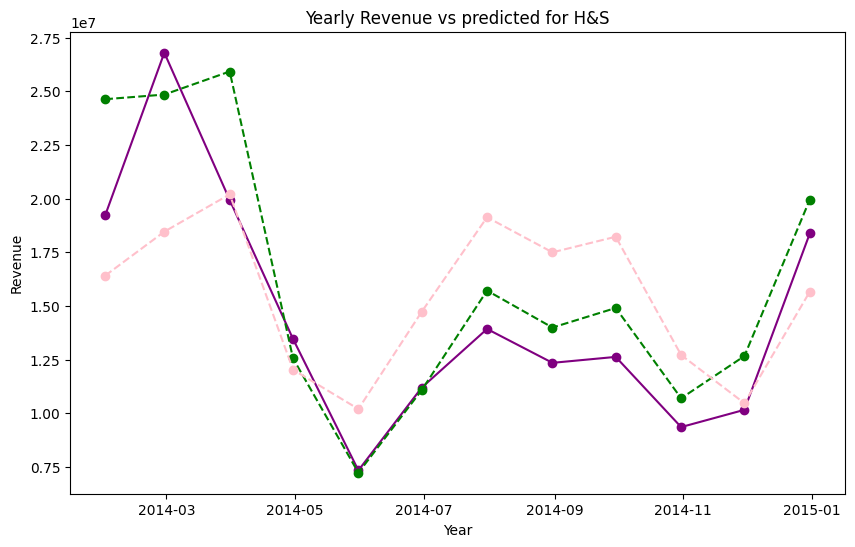

In [54]:
plt.figure(figsize=(10, 6))

plt.title('Yearly Revenue vs predicted for H&S')
plt.xlabel('Year')
plt.ylabel('Revenue')

plt.plot(dt4testing['date'], dt4testing['revenue'], color='purple', marker='o',
         label='Actual Revenue')
plt.plot(dt4testing['date'], dt4testing['mr_predicted'], color='green', marker='o',
         linestyle='dashed',
         label='MR Predicted Revenue')
plt.plot(dt4testing['date'], dt4testing['lm_predicted'], color='pink', marker='o',
         linestyle='dashed',
         label='LM Predicted Revenue')


The graph visually reinforces the evidence already established by the adjusted R² and MAPE. The predicted revenue line closely follows the actual revenue, indicating a strong fit. Compared to the simple linear regression model, the inclusion of the heatDD variable has reduced the gap between the actual and predicted values, resulting in improved predictive accuracy. Therefore, this multiple regression model provides more reliable revenue forecasts.